# Question 3: 3-Omniwheel Simulation
Simulate the 2D trajectory and state variables of a 3-wheel omnidirectional robot given wheel rotational speeds $u_1(t), u_2(t), u_3(t)$.

### Discrete Time Kinematic Model
$$ p_{\text{new}} = p_{\text{old}} + \dot{p} \Delta t $$
where,
$$ \dot{p} = \begin{bmatrix} \dot{x} \\ \dot{y} \\ \dot{\theta} \end{bmatrix} = r G^{-1} \begin{bmatrix} u_1 \\ u_2 \\ u_3 \end{bmatrix} = \frac{r}{3} \begin{bmatrix} -2\sin\theta & -2\cos\left(\theta + \frac{\pi}{6}\right) & 2\sin\left(\theta + \frac{\pi}{3}\right) \\[0.5em] 2\cos\theta & -2\cos\left(\theta - \frac{\pi}{3}\right) & -2\cos\left(\theta + \frac{\pi}{3}\right) \\[0.5em] \frac{1}{L} & \frac{1}{L} & \frac{1}{L} \end{bmatrix} \begin{bmatrix} u_1 \\ u_2 \\ u_3 \end{bmatrix} $$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def simulate(u1, u2, u3, r=0.10, L=0.25, time_epoch=0.1, duration=30.0):
    u1 = float(u1)
    u2 = float(u2)
    u3 = float(u3)

    t = np.arange(0, duration + time_epoch, time_epoch)
    n = len(t)
    
    x = np.zeros(n)
    y = np.zeros(n)
    theta = np.zeros(n)

    # Initial pose at origin with zero heading
    x[0] = 0.0
    y[0] = 0.0
    theta[0] = 0.0

    theta_dot = (r / (3.0 * L)) * (u1 + u2 + u3)
    if abs(theta_dot) < 1e-10:
        theta_dot = 0.0

    for i in range(n - 1):
        th_i = theta[i]

        # Inverted kinematic model: q_dot = r * G^(-1) * u
        x_dot = (r / 3.0) * (
            -2.0 * np.sin(th_i) * u1
            - 2.0 * np.cos(th_i + np.pi / 6.0) * u2
            + 2.0 * np.sin(th_i + np.pi / 3.0) * u3
        )
        y_dot = (r / 3.0) * (
            2.0 * np.cos(th_i) * u1
            - 2.0 * np.cos(th_i - np.pi / 3.0) * u2
            - 2.0 * np.cos(th_i + np.pi / 3.0) * u3
        )

        if abs(x_dot) < 1e-10:
            x_dot = 0.0
        if abs(y_dot) < 1e-10:
            y_dot = 0.0

        x[i + 1] = x[i] + x_dot * time_epoch
        y[i + 1] = y[i] + y_dot * time_epoch
        theta[i + 1] = theta[i] + theta_dot * time_epoch

    x[np.abs(x) < 1e-10] = 0.0
    y[np.abs(y) < 1e-10] = 0.0
    theta[np.abs(theta) < 1e-10] = 0.0

    return t, x, y, theta

def plot_case(t, x, y, theta, case_title):
    """Plot the 2D trajectory and state variables.
    Citation: LLM used to help write this matplotlib function.
    """
    fig = plt.figure(figsize=(13, 6))
    gs = gridspec.GridSpec(3, 2, figure=fig, width_ratios=[1.2, 1])

    # 1. Top-view 2D trajectory (x vs y)
    ax_traj = fig.add_subplot(gs[:, 0])
    ax_traj.plot(x, y, 'b-', linewidth=2, label='Trajectory')
    ax_traj.plot(x[0], y[0], 'go', markersize=8, label='Start (0, 0)')
    ax_traj.plot(x[-1], y[-1], 'ro', markersize=8, label=f'End ({x[-1]:.2f}, {y[-1]:.2f})')
    ax_traj.set_xlabel('x [m]', fontsize=11)
    ax_traj.set_ylabel('y [m]', fontsize=11)
    ax_traj.set_title(f'2D Trajectory: {case_title}', fontsize=12, fontweight='bold')
    ax_traj.axis('equal')
    ax_traj.grid(True, linestyle='--', alpha=0.6)
    ax_traj.legend(loc='best')

    # 2. x(t) vs time
    ax_x = fig.add_subplot(gs[0, 1])
    ax_x.plot(t, x, 'tab:blue', linewidth=1.5)
    ax_x.set_ylabel('x [m]', fontsize=10)
    ax_x.set_title('State Variables vs Time', fontsize=12, fontweight='bold')
    ax_x.grid(True, linestyle='--', alpha=0.6)

    # 3. y(t) vs time
    ax_y = fig.add_subplot(gs[1, 1], sharex=ax_x)
    ax_y.plot(t, y, 'tab:orange', linewidth=1.5)
    ax_y.set_ylabel('y [m]', fontsize=10)
    ax_y.grid(True, linestyle='--', alpha=0.6)

    # 4. theta(t) vs time
    ax_th = fig.add_subplot(gs[2, 1], sharex=ax_x)
    ax_th.plot(t, theta, 'tab:green', linewidth=1.5)
    ax_th.set_xlabel('Time t [s]', fontsize=11)
    ax_th.set_ylabel(r'$\theta$ [rad]', fontsize=10)
    ax_th.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

### Part (b).I: Rotation Inputs
$$ u_1 = -2.0\,\text{rad/s}, \quad u_2 = 1.0\,\text{rad/s}, \quad u_3 = 1.0\,\text{rad/s} $$

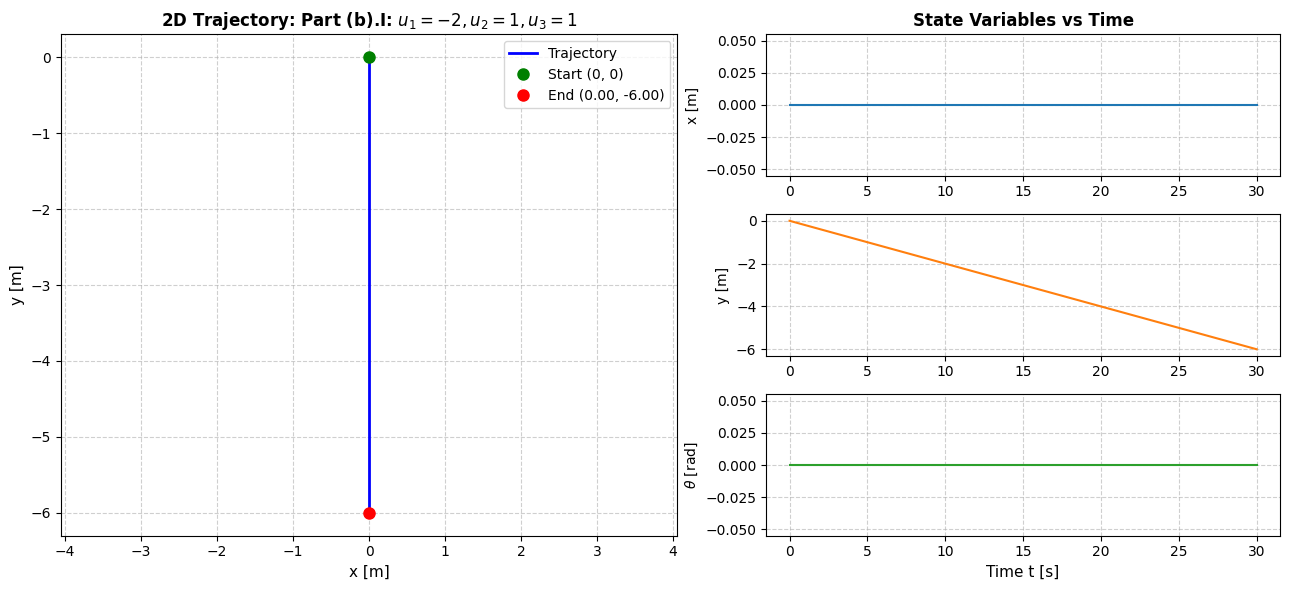

In [2]:
t, x, y, theta = simulate(u1=-2.0, u2=1.0, u3=1.0, time_epoch=0.1, duration=30.0)
plot_case(t, x, y, theta, r'Part (b).I: $u_1 = -2, u_2 = 1, u_3 = 1$')

### Part (b).II.1: Straight line with a slope of 60 degrees
Desired motion: $\frac{\dot{y}}{\dot{x}} = \tan(60^\circ) = \sqrt{3}, \quad \dot{\theta} = 0\,\text{rad/s}$

Choosing $\dot{x} = 1\,\text{m/s}, \quad \dot{y} = \sqrt{3}\,\text{m/s}, \quad \dot{\theta} = 0\,\text{rad/s}$:
$$ u_1 = 10\sqrt{3},\text{rad/s}, \quad u_2 = -10\sqrt{3},\text{rad/s}, \quad u_3 = 0\,\text{rad/s} $$

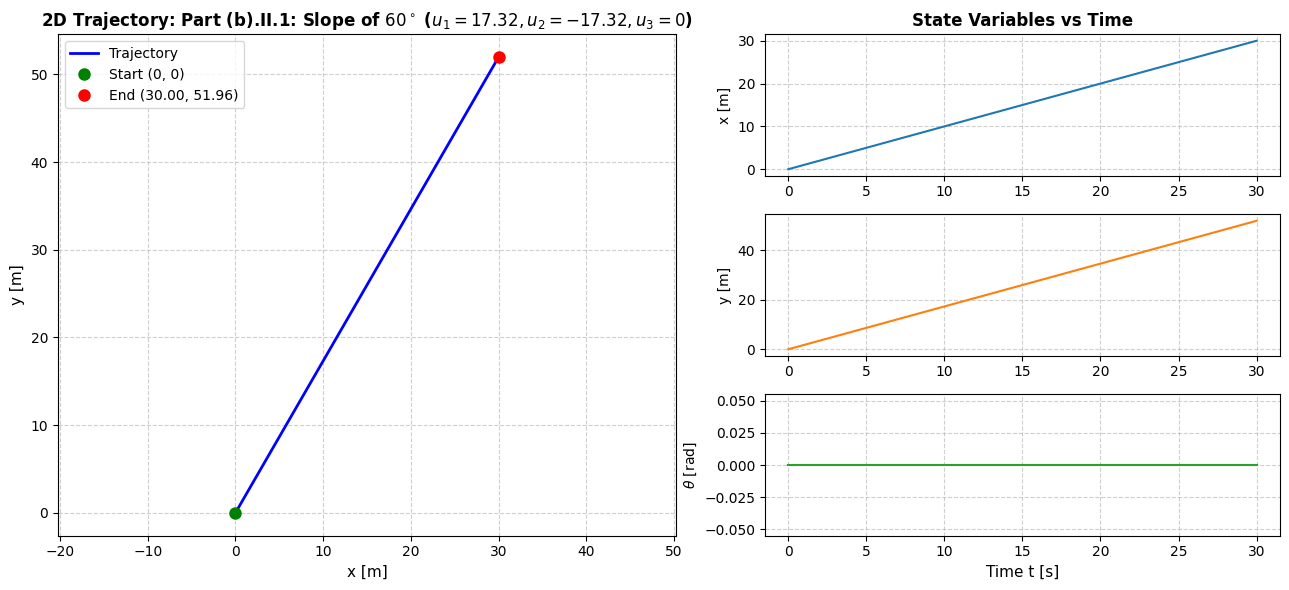

In [3]:
u1 = 10.0 * np.sqrt(3)
u2 = -10.0 * np.sqrt(3)
u3 = 0.0

t, x, y, theta = simulate(u1=u1, u2=u2, u3=u3, time_epoch=0.1, duration=30.0)
plot_case(t, x, y, theta, r'Part (b).II.1: Slope of $60^\circ$ ($u_1 = 17.32, u_2 = -17.32, u_3 = 0$)')

### Part (b).II.2: Two-meter diameter circle
Trajectory requirements:
- Diameter $D = 2\,\text{m} \implies \text{Radius } R = 1\,\text{m}$

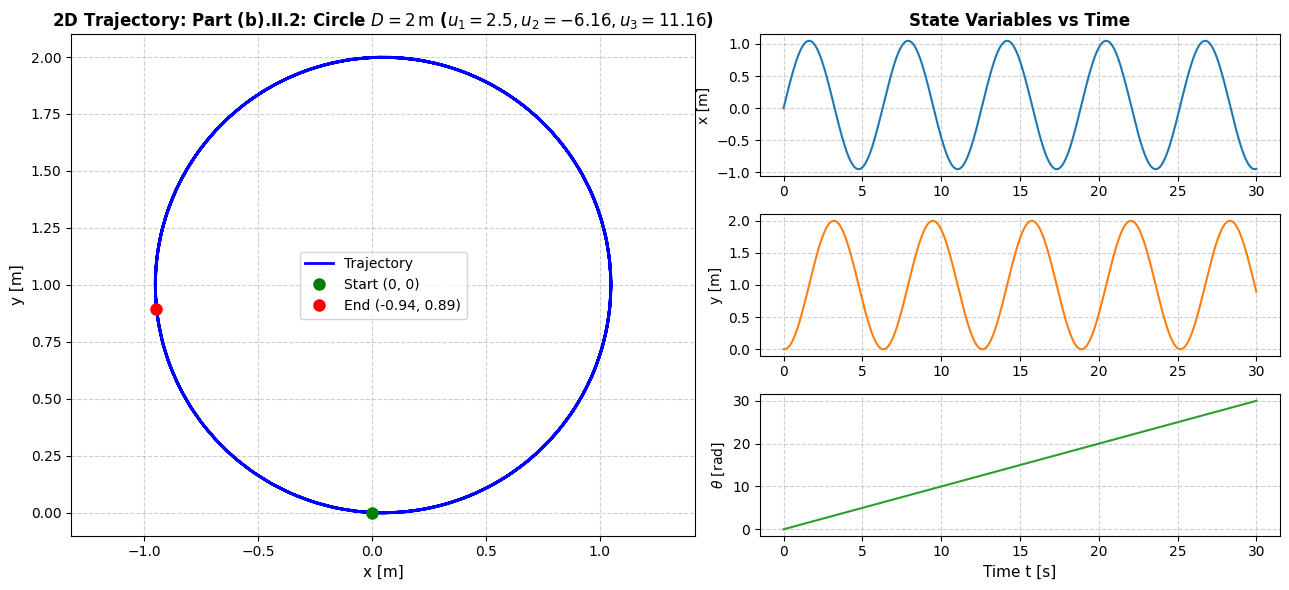

In [4]:
u1 = 2.5
u2 = 2.5 - 5.0 * np.sqrt(3)
u3 = 2.5 + 5.0 * np.sqrt(3)

t, x, y, theta = simulate(u1=u1, u2=u2, u3=u3, time_epoch=0.1, duration=30.0)
plot_case(t, x, y, theta, r'Part (b).II.2: Circle $D=2\,\mathrm{m}$ ($u_1 = 2.5, u_2 = -6.16, u_3 = 11.16$)')